In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd drive/MyDrive/

/content/drive/MyDrive


In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182596, 3]) torch.Size([182596])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22769, 3]) torch.Size([22769])


In [8]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

tanh_non_linearity = 5/3
hpreact_fan_in = n_embd * block_size
kaiming_init = tanh_non_linearity / np.sqrt(hpreact_fan_in)

C  = torch.randn((vocab_size, n_embd))
W1 = torch.randn((n_embd * block_size, n_hidden)) * kaiming_init  # * 0.2
b1 = torch.randn(n_hidden)                        * 0.01
W2 = torch.randn((n_hidden, vocab_size))          * 0.01
b2 = torch.randn(vocab_size)                      * 0

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


Loss Log
- original
- fix softmax confidently wrong
- fix tanh layer too saturated at initialization
- kaiming init

In [9]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3444


  10000/ 200000: 2.5886
  20000/ 200000: 2.2893
  30000/ 200000: 2.3946
  40000/ 200000: 2.1671
  50000/ 200000: 2.0932
  60000/ 200000: 1.9860
  70000/ 200000: 2.4400
  80000/ 200000: 2.1365
  90000/ 200000: 1.7994
 100000/ 200000: 2.4482
 110000/ 200000: 1.8155
 120000/ 200000: 2.3139
 130000/ 200000: 1.8919
 140000/ 200000: 1.8526
 150000/ 200000: 2.5093
 160000/ 200000: 1.9199
 170000/ 200000: 1.8766
 180000/ 200000: 2.5136
 190000/ 200000: 2.0145


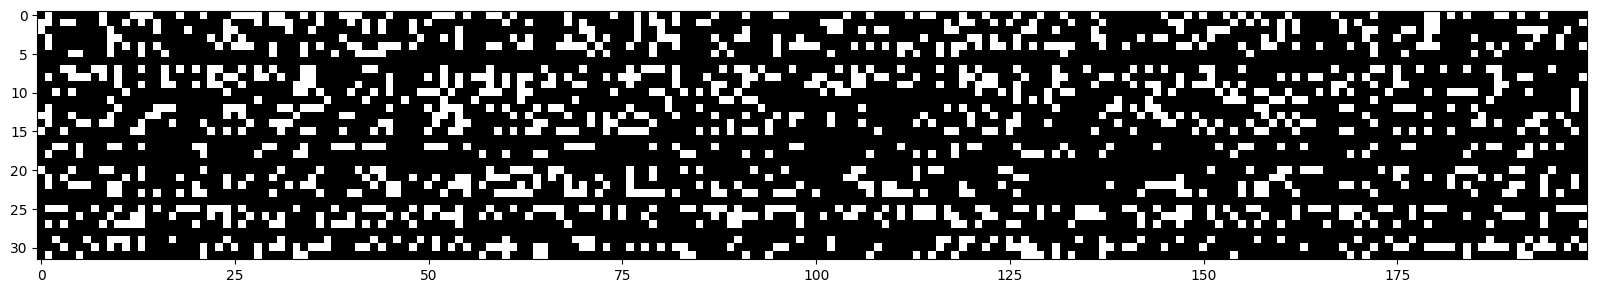

In [10]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

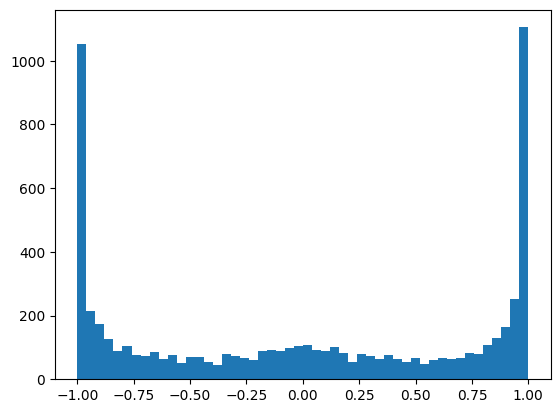

In [11]:
plt.hist(h.view(-1).tolist(), 50);

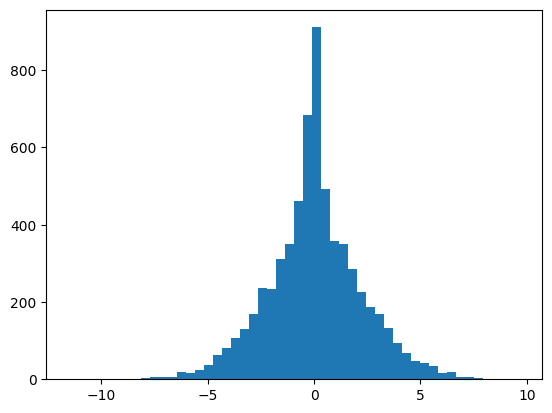

In [12]:
plt.hist(hpreact.view(-1).tolist(), 50);

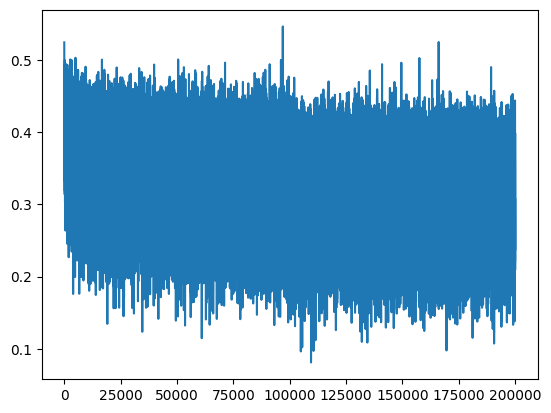

In [13]:
plt.plot(lossi)

In [14]:
logits[0]

tensor([ 2.3488,  6.7488, -2.9526, -1.6539, -0.2122,  6.9525, -0.9102, -4.6151,
        -0.3911,  6.3361, -3.3567, -1.8903,  1.9659, -1.9531, -1.8388,  5.3865,
        -4.8576, -4.0592, -0.4789, -1.0534, -1.7527,  1.9047, -1.6920, -1.5908,
        -2.7389,  5.6886,  0.2370], grad_fn=<SelectBackward0>)

In [15]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.041693925857544
val 2.105724811553955


In [16]:
for _ in range(20):
    
    out = []
    context = [0] * block_size
    
    while True:
        # forward pass the nn
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h  = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs  = F.softmax(logits, dim=1)
        # sample from distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift context window and track samples
        context = context[1:] + [ix]
        out.append(ix)
        # if "." is sampled break
        if ix == 0:
            break
        
    print(''.join(itos[i] for i in out)) # decode and print word

carielen.
ram.
damyakinnrioryn.
judian.
tayas.
olso.
ari.
mika.
everiyah.
ayline.
cheshamardo.
joisiyonanyrahalailynna.
corrigon.
dhatha.
nelin.
melianella.
damaryazleia.
sachtan.
lailandtogayannighba.
trimneevah.
